<a href="https://colab.research.google.com/github/thatcherty/ML-Algo-Selection/blob/main/ML_Algo_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Algo Selection

In [50]:
!pip install ucimlrepo scikeras openml
!pip uninstall -y scikit-learn umap-learn hdbscan
!pip install scikit-learn==1.5.2

# Common
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from pandas.errors import ParserError
import warnings
from sklearn.exceptions import ConvergenceWarning
import os
from google.colab import drive
import openpyxl
import gc
import openml

from ucimlrepo import fetch_ucirepo

import sklearn

import scikeras
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, accuracy_score
from scikeras.wrappers import KerasClassifier
import keras
import tensorflow as tf


dataset = fetch_ucirepo(id=1)
print(dataset.metadata)


print("sklearn:", sklearn.__version__)
print("scikeras:", scikeras.__version__)
print("keras:", keras.__version__)
print("tensorflow:", tf.__version__)

Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
  Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)


{'uci_id': 1, 'name': 'Abalone', 'repository_url': 'https://archive.ics.uci.edu/dataset/1/abalone', 'data_url': 'https://archive.ics.uci.edu/static/public/1/data.csv', 'abstract': 'Predict the age of abalone from physical measurements', 'area': 'Biology', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Tabular'], 'num_instances': 4177, 'num_features': 8, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['Rings'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C55C7W', 'creators': ['Warwick Nash', 'Tracy Sellers', 'Simon Talbot', 'Andrew Cawthorn', 'Wes Ford'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting the age of abalone from physical measurements.  The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- 

In [ ]:
import argparse
import re
from pathlib import Path
from urllib.parse import parse_qsl, urlencode, urljoin, urlparse, urlunparse

import requests
from bs4 import BeautifulSoup


BASE_URL = (
    "https://archive.ics.uci.edu/datasets"
    "?Task=Classification"
    "&Types=Multivariate"
    "&Types=Tabular"
    "&Python=true"
    "&skip=0"
    "&take=10"
    "&sort=desc"
    "&orderBy=NumHits"
    "&search="
)

USER_AGENT = (
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 "
    "(KHTML, like Gecko) Chrome/123.0 Safari/537.36"
)


def build_page_url(base_url: str, *, skip: int, take: int) -> str:
    parsed = urlparse(base_url)

    # Keep repeated query params like Types=...
    params = parse_qsl(parsed.query, keep_blank_values=True)

    new_params = []
    skip_set = False
    take_set = False

    for key, value in params:
        if key == "skip":
            new_params.append(("skip", str(skip)))
            skip_set = True
        elif key == "take":
            new_params.append(("take", str(take)))
            take_set = True
        else:
            new_params.append((key, value))

    if not skip_set:
        new_params.append(("skip", str(skip)))
    if not take_set:
        new_params.append(("take", str(take)))

    new_query = urlencode(new_params, doseq=True)
    return urlunparse(parsed._replace(query=new_query))


def extract_total_count(page_text: str) -> int | None:
    match = re.search(r"\b\d+\s+to\s+\d+\s+of\s+(\d+)\b", page_text)
    return int(match.group(1)) if match else None


def parse_dataset_links(html: str, page_url: str) -> list[int]:
    soup = BeautifulSoup(html, "html.parser")

    anchors = soup.select("a[href*='/dataset/']")
    dataset_ids = []
    seen = set()

    for a in anchors:
        href = (a.get("href") or "").strip()
        if not href:
            continue

        full_url = urljoin(page_url, href)

        match = re.search(r"/dataset/(\d+)", full_url)
        if not match:
            continue

        dataset_id = int(match.group(1))

        if dataset_id in seen:
            continue
        seen.add(dataset_id)
        dataset_ids.append(dataset_id)

    return dataset_ids


def scrape_all_datasets(base_url: str, *, take: int = 25, timeout: int = 30) -> list[int]:
    session = requests.Session()
    session.headers.update({"User-Agent": USER_AGENT})

    all_ids = []
    seen_ids = set()
    skip = 0
    total_count = None

    while True:
        page_url = build_page_url(base_url, skip=skip, take=take)

        response = session.get(page_url, timeout=timeout)
        response.raise_for_status()

        html = response.text
        text = BeautifulSoup(html, "html.parser").get_text(" ", strip=True)

        if total_count is None:
            total_count = extract_total_count(text)
            print(f"Total count reported: {total_count}")

        page_ids = parse_dataset_links(html, page_url)
        new_ids = [dataset_id for dataset_id in page_ids if dataset_id not in seen_ids]

        if not new_ids:
            break

        for dataset_id in new_ids:
            seen_ids.add(dataset_id)
            all_ids.append(dataset_id)

        if total_count is not None and len(all_ids) >= total_count:
            break

        if len(page_ids) < take:
            break

        skip += take

    return all_ids


def get_data() -> list[int]:
    parser = argparse.ArgumentParser(
        description="Scrape UCI dataset IDs matching the filtered URL."
    )
    parser.add_argument("--url", default=BASE_URL, help="Filtered UCI listing URL to scrape.")
    parser.add_argument(
        "--take",
        type=int,
        default=25,
        help="Rows requested per page while paginating."
    )
    parser.add_argument(
        "--timeout",
        type=int,
        default=30,
        help="HTTP timeout in seconds."
    )
    args = parser.parse_args([])

    ids = scrape_all_datasets(args.url, take=args.take, timeout=args.timeout)

    if not ids:
        raise SystemExit("No dataset IDs were found. The page structure may have changed.")

    return ids

In [ ]:
# extract ids to exclude based on characertistics

exclude_types: list[str] = ["Time-Series", "Image", "Sequential", "Spatiotemporal", "Text", "Other"]

ids = get_data()
print(ids)

excluded_ids = []
final_ids = []

for dataset_id in ids:
    try:
        dataset = fetch_ucirepo(id=dataset_id)
        y = dataset.data.targets

        if y is None or y.empty:
          print(f"Skipping dataset {dataset_id} ({dataset.metadata['name']}) due to no target variables.")
          excluded_ids.append(dataset_id)
          continue

        # get min class size
        min_class_size = y.value_counts().min()

        if min_class_size < 2:
          print(f"Class size < 2 for {dataset_id}")
          excluded_ids.append(dataset_id)
          continue

        final_ids.append(dataset_id)
    except ParserError as e:
        print(f"Skipping {dataset_id} due to parse error: {e}")
        excluded_ids.append(dataset_id)
        continue
    except Exception as e:
        print(f"Skipping {dataset_id} due to fetch error: {e}")
        excluded_ids.append(dataset_id)
        continue

    characteristics = dataset.metadata.get("characteristics") or []

    if any(exclude in characteristics for exclude in exclude_types):
        print(f"Skipping {dataset_id} due to characteristics: {characteristics}")
        excluded_ids.append(dataset_id)
        continue

print("Failed dataset count:", len(excluded_ids))



Total count reported: 167
[53, 45, 186, 17, 222, 2, 320, 352, 109, 19, 697, 350, 144, 73, 544, 1, 891, 94, 468, 159, 15, 296, 14, 519, 602, 27, 20, 336, 242, 601, 292, 174, 327, 80, 42, 545, 267, 856, 31, 111, 555, 967, 62, 332, 597, 863, 373, 59, 529, 579, 936, 942, 46, 848, 563, 890, 52, 878, 383, 225, 572, 850, 857, 887, 445, 158, 151, 101, 571, 145, 938, 915, 484, 880, 864, 365, 110, 547, 759, 244, 193, 732, 763, 33, 105, 76, 143, 451, 176, 603, 198, 12, 16, 264, 379, 471, 760, 212, 39, 461, 172, 467, 536, 90, 503, 50, 47, 419, 161, 117, 357, 81, 485, 911, 58, 342, 537, 827, 30, 329, 582, 799, 247, 40, 43, 26, 565, 146, 149, 13, 270, 38, 372, 148, 913, 367, 257, 277, 713, 300, 54, 28, 728, 83, 722, 22, 567, 184, 78, 107, 95, 63, 755, 3, 70, 44, 75, 91, 23, 74, 32, 96, 82, 18, 88, 8, 147]
Class size < 2 for 320
Skipping dataset 352 (Online Retail) due to no target variables.
Class size < 2 for 1


/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Class size < 2 for 242
Class size < 2 for 601


/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0,5,6,12,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Skipping dataset 555 (Apartment for Rent Classified) due to no target variables.
Class size < 2 for 332
Class size < 2 for 597
Class size < 2 for 373
Class size < 2 for 579
Skipping 942 due to characteristics: ['Tabular', 'Sequential', 'Multivariate']
Skipping dataset 383 (Cervical Cancer (Risk Factors)) due to no target variables.
Class size < 2 for 445
Class size < 2 for 938
Skipping dataset 484 (Travel Reviews) due to no target variables.
Skipping 864 due to characteristics: ['Multivariate', 'Time-Series']
Class size < 2 for 547
Class size < 2 for 193
Skipping 763 due to characteristics: ['Tabular', 'Multivariate', 'Other']
Skipping 264 due to characteristics: ['Multivariate', 'Sequential', 'Time-Series']
Class size < 2 for 471
Skipping dataset 760 (Multivariate Gait Data) due to no target variables.
Skipping dataset 461 (Drug Reviews (Druglib.com)) due to no target variables.
Skipping 172 due to characteristics: ['Multivariate', 'Sequential', 'Time-Series']
Skipping dataset 467 (St

In [ ]:
old_ids = [53, 45, 186, 17, 222, 2, 109, 19, 697, 350, 144, 73, 544, 891, 94, 468, 159, 15, 296, 14, 519, 602, 27, 20, 336, 292, 174, 327, 80, 42, 545, 267, 856, 31, 111, 967, 62, 863, 59, 529, 936, 46, 848, 563, 890, 52, 878, 225, 572, 850, 857, 887, 158, 151, 101, 571, 145, 915, 880, 365, 110, 759, 244, 732, 33, 105, 76, 143, 451, 176, 603, 198, 12, 16, 379, 212, 39, 50, 503, 47, 419, 161, 117, 81, 58, 342, 537, 827, 30, 329, 582, 43, 26, 565, 146, 13, 372, 148, 367, 257, 277, 300, 54, 28, 728, 722, 22, 184, 78, 107, 95, 63, 3, 70, 44, 75, 91, 23, 74, 32, 96, 88, 147]

ids = [45,186,17,222,2,109,19,697,350,144,73,544,891,94,468,159,15,296,14,519,602,27,20,336,292,174,327,80,42,545,267,856,31,111,62,863,59,529,936,46,848,563,890,52,878,225,572,850,857,887,158,151,101,571,145,915,880,365,110,759,244,732,33,105,76,143,451,176,603,198,12,16,379,212,39,50,503,47,419,161,117,81,58,342,537,827,30,329,582,43,26,565,146,13,372,148,367,257,277,300,54,28,728,722,22,184,78,107,95,63,3,75,91,23,74,96,88,147]

print(len(ids))

datasets = []

for dataset_id in ids:
  datasets.append(fetch_ucirepo(id=dataset_id))

118


/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [2]:
from sklearn.metrics.cluster import entropy
import openml

from scikeras.wrappers import KerasClassifier
import keras
keras.utils.set_random_seed(0)
import numpy as np


class NNModel():


    @staticmethod
    def _create_model(meta):

        import tensorflow as tf
        tf.keras.backend.clear_session()
        keras.utils.set_random_seed(0)

        import os
        os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

        n_features = meta["n_features_in_"]
        n_classes = meta["n_classes_"]

        dense_multiplier = 10
        dense_units = dense_multiplier*n_features
        # print(f"Number of proposed dense units: {dense_units}")

        dense_units_min = 64
        dense_units_max = 192

        n_units = min(dense_units, dense_units_max)
        n_units = max(dense_units_min, n_units)

        # act = 'swish'
        act = 'relu'
        initializer = 'he_normal'
        model = keras.Sequential()
        model.add(keras.layers.Input(shape=(n_features,)))
        model.add(keras.layers.Dropout(rate=0.05))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Dense(units=n_units, activation=act, kernel_initializer=initializer))
        model.add(keras.layers.Dropout(rate=0.2))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Dense(n_classes, activation='softmax',dtype='float32'))
        model.build(input_shape=(None, n_features))
        optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
        loss = keras.losses.SparseCategoricalCrossentropy()
        model.compile(loss=loss, optimizer=optimizer, metrics=['accuracy'], )
        return model


    def __init__(self):
        return


    def get_model(self):
        wrapped = KerasClassifier(
            model=self._create_model,
            batch_size=32,
            epochs=20,
            verbose=0,
            callbacks=[
                keras.callbacks.CSVLogger("training_results.csv", append=True),
                keras.callbacks.EarlyStopping(
                    monitor="loss",
                    patience=3,
                    restore_best_weights=True,
                ),
                ],
        )
        return wrapped

# get model features
def extract_features(dataset, algo, conf):
  X = dataset.data.features
  y = dataset.data.targets
  # Get dataset features
  ID = dataset.metadata['uci_id']
  name = dataset.metadata['name']
  feature_count = dataset.metadata['num_features']
  instance_count = dataset.metadata['num_instances']
  missing_values = dataset.metadata['has_missing_values']
  class_count = len(y.nunique())
  imbalance_ratio =  y.value_counts().max() / y.value_counts().min()
  probs = y.value_counts(normalize=True)
  entropy = -np.sum(probs * np.log2(probs))

  if len(probs) > 1:
      entropy /= np.log2(len(probs))

  #p/n ratio: if high, logistic regression more likely
  feature_instance_ratio = feature_count / instance_count

  #identifying column types: (numeric or binary)
  num_X = X.select_dtypes(include=[np.number])
  num_feature_count = num_X.shape[1]

  #avg correlation: if high, decision tree more likely
  #redundancy check
  avg_corr = 0

  if num_feature_count > 1:
    corr_matrix = num_X.corr().abs()

    #sum, then subtract diagonals and average everything else
    off_diag = corr_matrix.values.sum() - num_feature_count
    denom = num_feature_count**2 - num_feature_count
    avg_corr = off_diag / denom


  #cat ratio: if high, decision tree more likely
  cat_ratio = 0
  if feature_count > 0:
    cat_ratio = (feature_count -  num_feature_count)/feature_count


  #avg skewness: if high, decision tree more likely
  avg_skew = 0
  if num_feature_count > 0:
    avg_skew = num_X.skew().abs().mean()


  new_row = {'ID':ID, 'Source': 2, 'Dataset': name, 'Feature Count': feature_count, 'Instances': instance_count, 'Class Count': class_count, 'Missing Values': missing_values, 'Average Correlation':avg_corr, 'Average Skew':avg_skew, 'P/N Ratio': feature_instance_ratio, 'Cat Ratio': cat_ratio,  'Class Imbalance': imbalance_ratio, 'Entropy': entropy , "Recommended Algorithm": algo,"Expected Confidence": conf}

  return new_row

# for datasets with columns of same name :(
def make_unique_columns(df):
    cols = df.columns
    seen = {}
    new_cols = []

    for col in cols:
        if col not in seen:
            seen[col] = 0
            new_cols.append(col)
        else:
            seen[col] += 1
            new_cols.append(f"{col}_{seen[col]}")

    df.columns = new_cols
    return df

# preprocessing
def build_preprocessor(X: pd.DataFrame):

  # rename non-unique columns
  if (X.columns.duplicated().any()):
    X = make_unique_columns(X)

  # Detect column types
  numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
  categorical_cols = [col for col in X.columns if col not in numeric_cols]

  # Numeric preprocessing
  numeric_pipeline = Pipeline([
      ("imputer", SimpleImputer(strategy="median")),
      ("scaler", StandardScaler())
  ])

  # Categorical preprocessing
  categorical_pipeline = Pipeline([
      ("imputer", SimpleImputer(strategy="most_frequent")),
      ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
  ])

  # Combine both
  preprocessor = ColumnTransformer([
      ("num", numeric_pipeline, numeric_cols),
      ("cat", categorical_pipeline, categorical_cols)
  ])

  return preprocessor


# simulate train and test
def run_simulation(X, y, model, name, log_all = 0, log_conf = 0) -> float:
    # preprocessor will determine what preprocessing to perform on what columns
    preprocessor = build_preprocessor(X)

    # preprocess data and select
    pipe = Pipeline([('preprocessor', preprocessor), (name, model)])


    # split data into 5 sections
    # select 4 of 5 for train and last for test
    # do this selection 5 times
    min_class_size = y.value_counts().min()

    if min_class_size < 2:
        print("Class size < 2")

    n_splits = min(5, min_class_size)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

    # fits model on each of the 5 train/test splits
    # reports all accuracy and f1 for the 5 splits
    results = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=["f1_macro"],
        return_train_score=False
    )

    # extract results
    f1_scores = results["test_f1_macro"]

    # get mean and std f1 among 5 splits
    # used to determine confidence score
    mean_f1 = np.mean(f1_scores)
    std_f1 = np.std(f1_scores)

    # determine confidence score
    # high f1 score and low std is preferred
    confidence_score = mean_f1 - std_f1

    # optional logging
    if log_all:
      print(f"{name} {dataset.metadata["uci_id"]} mean F1: {mean_f1:.4f}")
      print(f"{name} {dataset.metadata["uci_id"]} std F1: {std_f1:.4f}")

    if log_all or log_conf:
      print(f"{name} {dataset.metadata["uci_id"]} confidence score (mean F1 - std F1): {confidence_score:.4f}")

    return confidence_score

# determine best model
def get_best_model(model_scores):
  best_model = max(model_scores, key=model_scores.get)

  ties = [model for model, score in model_scores.items() if score == model_scores[best_model]]

  # choose simpler model of tied models
  if len(ties) > 1:
    preference = ["Logistic", "Decision Tree", "Neural Network"]
    for model in preference:
      if model in ties:
        best_model = model
        break
  else:
    best_model = ties[0]

  return best_model, model_scores[best_model]


def get_openml_ids():
    df = openml.datasets.list_datasets(output_format="dataframe")

    # Only keep datasets that have a target (classification-like)
    df = df[
        (df["NumberOfClasses"].notna()) &
        (df["NumberOfClasses"] > 1)
    ]

    ids = df["did"].tolist()

    print(f"Collected {len(ids)} OpenML dataset IDs")

    return ids

def fetch_openml_dataset(id):
    dataset = openml.datasets.get_dataset(id)

    if dataset.default_target_attribute is None:
        raise ValueError(f"No default target for dataset {id}")

    X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)

    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    if not isinstance(y, pd.Series):
        y = pd.Series(y, name=dataset.default_target_attribute)

    class DataWrapper:
        def __init__(self, features, targets):
            self.features = features
            self.targets = targets

    class DatasetWrapper:
        def __init__(self, metadata, data):
            self.metadata = metadata
            self.data = data

    metadata = {
        "uci_id": dataset.dataset_id,
        "name": dataset.name,
        "num_features": X.shape[1],
        "num_instances": X.shape[0],
        "has_missing_values": int(X.isna().sum().sum() > 0),
    }

    data = DataWrapper(
        features=X,
        targets=pd.DataFrame({dataset.default_target_attribute: y})
    )

    wrapped = DatasetWrapper(metadata=metadata, data=data)
    return wrapped

In [ ]:
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/College/Current Courses/Advanced Machine Learning/Project/Data/Data.xlsx'
sheet_name = 'Data'
existing_df = pd.read_excel(file_path, sheet_name=sheet_name, engine='openpyxl')
start_row = len(existing_df) + 1
start = start_row
end = len(datasets)
log = 0

print(f"Starting from dataset number {start} and ending with {end}")

# exclude convergence warnings for clearer logging
if True:
  warnings.filterwarnings("ignore", category=ConvergenceWarning)

test_log = 0
test_nn = 1
test_tree = 0


for dataset in datasets[start-1:end]:
  model_scores = {}

  if (start_row % 10 == 0):
    print(f"Completed {start_row} datasets total")

  # Get the targets for the current dataset
  current_dataset_targets_df = dataset.data.targets

  # This should be done by exclusion previously, but keep just in case
  # Skip if no target variables or if the target DataFrame is empty
  if current_dataset_targets_df is None or current_dataset_targets_df.empty:
    print(f"Skipping dataset {dataset.metadata['uci_id']} ({dataset.metadata['name']}) due to no target variables.")
    continue

  # Get the list of target column names to iterate over
  targets_to_process_names = current_dataset_targets_df.columns.tolist()

  # model assessment loop to account for multiple target var
  for target_col_name in targets_to_process_names:
    X = dataset.data.features
    y = current_dataset_targets_df[target_col_name]

    if test_log:
      # define model
      name = "Logistic Regression"
      model = LogisticRegression(
          #regularization strength
          C=1.0,

          #regularitaion type
          penalty ='l1',

          #optimization
          solver = 'saga',

          #convergence
          max_iter=1000
      )

      # run simulation
      # this handles preprocessing and data splitting
      model_scores[name] = run_simulation(X, y, model, name, log_conf=0)

    if test_nn:
      # define model
      name = "Neural Network"
      model = NNModel().get_model()

      # run simulation
      # this handles preprocessing and data splitting
      model_scores[name] = run_simulation(X, y, model, name, log_conf=0)

    if test_tree:
      # define model
      name = "Tree"
      model = RandomForestClassifier()

      # run simulation
      # this handles preprocessing and data splitting
      model_scores[name] = run_simulation(X, y, model, name, log_conf=0)


    # Determine Recommended Algorithm
    best_model, confidence = get_best_model(model_scores)

    if (log):
      print(f"Recommended Algorithm for {dataset.metadata['uci_id']}: {best_model} with confidence {confidence}")

    # extract metadata dataset features and track result
    new_row_df = pd.DataFrame([extract_features(dataset, best_model, confidence)])

    with pd.ExcelWriter(file_path, mode='a', engine='openpyxl', if_sheet_exists='overlay') as writer:
      new_row_df.to_excel(writer, sheet_name=sheet_name, startrow=start_row, index=False, header=False)

    start_row += 1
    del new_row_df

  del X, y, dataset
  gc.collect()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Starting from dataset number 1 and ending with 118


Exception ignored in: <function WeakKeyDictionary.__init__.<locals>.remove at 0x78b171e209a0>
Traceback (most recent call last):
  File "/usr/lib/python3.12/weakref.py", line 369, in remove
    def remove(k, selfref=ref(self)):

KeyboardInterrupt: 
Exception ignored in: <function _xla_gc_callback at 0x78b16cb32ac0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/lib/__init__.py", line 127, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
import openml

openml.datasets.list_datasets(output_format="dataframe")

,did,name,version,uploader,status,format,MajorityClassSize,MaxNominalAttDistinctValues,MinorityClassSize,NumberOfClasses,NumberOfFeatures,NumberOfInstances,NumberOfInstancesWithMissingValues,NumberOfMissingValues,NumberOfNumericFeatures,NumberOfSymbolicFeatures
1,1,anneal,2,1,active,ARFF,684.0,8.0,8.0,5.0,39.0,898.0,0.0,0.0,6.0,33.0
2,2,anneal,1,1,active,ARFF,684.0,7.0,8.0,5.0,39.0,898.0,898.0,22175.0,6.0,33.0
3,3,kr-vs-kp,1,1,active,ARFF,1669.0,3.0,1527.0,2.0,37.0,3196.0,0.0,0.0,0.0,37.0
4,4,labor,1,1,active,ARFF,37.0,3.0,20.0,2.0,17.0,57.0,56.0,326.0,8.0,9.0
5,5,arrhythmia,1,1,active,ARFF,245.0,13.0,2.0,13.0,280.0,452.0,384.0,408.0,206.0,74.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47177,47177,check_times,1,26891,active,arff,NaN,NaN,NaN,0.0,24.0,13626.0,0.0,0.0,24.0,0.0
47178,47178,wa_churn,1,26891,active,arff,NaN,NaN,NaN,0.0,20.0,7032.0,0.0,0.0,10.0,10.0
47185,47185,test_dataset_5000,1,55300,active,arff,NaN,NaN,NaN,0.0,3.0,5000.0,0.0,0.0,3.0,0.0
47186,47186,test_dataset_10000,1,55300,active,arff,NaN,NaN,NaN,0.0,3.0,10000.0,0.0,0.0,3.0,0.0


In [ ]:
ids = get_openml_ids()
print(ids)

Collected 2705 OpenML dataset IDs
[1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 59, 60, 61, 62, 70, 71, 72, 73, 74, 75, 76, 77, 78, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 171, 172, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277, 278, 279, 285, 293, 300, 307, 310, 311, 312, 313, 316, 327, 328, 329, 333, 334, 335, 336, 337, 338, 339, 340, 342, 343, 346, 350, 351, 354, 357, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 3

In [ ]:
ids = [1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 59, 60, 61, 62, 70, 71, 72, 73, 74, 75, 76, 77, 78, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 171, 172, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277, 278, 279, 285, 293, 300, 307, 310, 311, 312, 313, 316, 327, 328, 329, 333, 334, 335, 336, 337, 338, 339, 340, 342, 343, 346, 350, 351, 354, 357, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 443, 444, 446, 448, 449, 450, 451, 452, 453, 454, 455, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 472, 473, 474, 475, 476, 477, 479, 480, 481, 488, 554, 679, 682, 683, 685, 694, 713, 714, 715, 716, 717, 718, 719, 720, 721, 722, 723, 724, 725, 726, 727, 728, 729, 730, 731, 732, 733, 734, 735, 736, 737, 738, 739, 740, 741, 742, 743, 744, 745, 746, 747, 748, 749, 750, 751, 752, 753, 754, 755, 756, 757, 758, 759, 760, 761, 762, 763, 764, 765, 766, 767, 768, 769, 770, 771, 772, 773, 774, 775, 776, 777, 778, 779, 780, 782, 783, 784, 785, 786, 787, 788, 789, 790, 791, 792, 793, 794, 795, 796, 797, 798, 799, 800, 801, 802, 803, 804, 805, 806, 807, 808, 810, 811, 812, 813, 814, 815, 816, 817, 818, 819, 820, 821, 823, 824, 825, 826, 827, 828, 829, 830, 831, 832, 833, 834, 835, 836, 837, 838, 839, 840, 841, 842, 843, 844, 845, 846, 847, 848, 849, 850, 851, 852, 853, 854, 855, 857, 858, 859, 860, 861, 862, 863, 864, 865, 866, 867, 868, 869, 870, 871, 873, 874, 875, 876, 877, 878, 879, 880, 881, 882, 884, 885, 886, 887, 888, 889, 890, 891, 892, 893, 894, 895, 896, 897, 898, 899, 900, 901, 902, 903, 904, 905, 906, 907, 908, 909, 910, 911, 912, 913, 914, 915, 916, 917, 918, 919, 920, 921, 922, 923, 924, 925, 926, 927, 928, 929, 930, 931, 932, 933, 934, 935, 936, 937, 938, 939, 940, 941, 942, 943, 944, 945, 946, 947, 949, 950, 951, 952, 953, 954, 955, 956, 957, 958, 959, 960, 961, 962, 963, 964, 965, 966, 967, 968, 969, 970, 971, 972, 973, 974, 975, 976, 977, 978, 979, 980, 981, 982, 983, 984, 985, 986, 987, 988, 989, 990, 991, 992, 993, 994, 995, 996, 997, 998, 999, 1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1037, 1038, 1039, 1040, 1041, 1042, 1044, 1045, 1046, 1047, 1048, 1049, 1050, 1053, 1054, 1055, 1056, 1057, 1059, 1060, 1061, 1062, 1063, 1064, 1065, 1066, 1067, 1068, 1069, 1071, 1073, 1075, 1077, 1078, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1087, 1088, 1100, 1101, 1102, 1104, 1106, 1107, 1109, 1110, 1111, 1112, 1113, 1114, 1115, 1116, 1117, 1119, 1120, 1121, 1122, 1123, 1124, 1125, 1126, 1127, 1128, 1129, 1130, 1131, 1132, 1133, 1134, 1135, 1136, 1137, 1138, 1139, 1140, 1141, 1142, 1143, 1144, 1145, 1146, 1147, 1148, 1149, 1150, 1151, 1152, 1153, 1154, 1155, 1156, 1157, 1158, 1159, 1160, 1161, 1162, 1163, 1164, 1165, 1166, 1167, 1169, 1177, 1178, 1179, 1180, 1181, 1182, 1183, 1185, 1186, 1205, 1209, 1211, 1212, 1214, 1216, 1217, 1218, 1219, 1220, 1222, 1226, 1233, 1235, 1236, 1237, 1238, 1240, 1241, 1242, 1351, 1352, 1353, 1354, 1355, 1356, 1357, 1358, 1359, 1360, 1361, 1362, 1363, 1364, 1365, 1366, 1367, 1368, 1369, 1370, 1371, 1372, 1373, 1374, 1375, 1376, 1377, 1378, 1379, 1380, 1381, 1382, 1383, 1384, 1385, 1386, 1387, 1388, 1389, 1390, 1391, 1392, 1393, 1394, 1395, 1396, 1397, 1398, 1399, 1400, 1401, 1402, 1403, 1404, 1405, 1406, 1407, 1408, 1409, 1410, 1412, 1413, 1441, 1442, 1443, 1444, 1446, 1447, 1448, 1449, 1450, 1451, 1452, 1453, 1455, 1457, 1458, 1459, 1460, 1461, 1462, 1463, 1464, 1465, 1466, 1467, 1468, 1471, 1472, 1473, 1475, 1476, 1477, 1478, 1479, 1480, 1481, 1482, 1483, 1484, 1485, 1486, 1487, 1488, 1489, 1490, 1491, 1492, 1493, 1494, 1495, 1496, 1497, 1498, 1499, 1500, 1501, 1502, 1503, 1504, 1506, 1507, 1508, 1509, 1510, 1511, 1512, 1513, 1514, 1515, 1516, 1517, 1518, 1519, 1520, 1523, 1524, 1525, 1526, 1527, 1528, 1529, 1530, 1531, 1532, 1533, 1534, 1535, 1536, 1537, 1538, 1539, 1540, 1541, 1542, 1543, 1544, 1545, 1546, 1547, 1548, 1549, 1551, 1552, 1553, 1554, 1555, 1556, 1557, 1558, 1559, 1560, 1561, 1562, 1563, 1564, 1565, 1566, 1567, 1568, 1569, 1590, 1596, 1597, 1600, 4134, 4135, 4136, 4137, 4153, 4154, 4329, 4340, 4534, 4538, 4541, 4552, 6332, 23380, 23381, 23499, 23512, 23517, 40474, 40475, 40476, 40477, 40478, 40496, 40497, 40498, 40499, 40514, 40515, 40516, 40517, 40518, 40519, 40520, 40536, 40588, 40589, 40590, 40591, 40592, 40593, 40594, 40595, 40596, 40597, 40645, 40646, 40647, 40648, 40649, 40650, 40660, 40663, 40664, 40665, 40666, 40668, 40669, 40670, 40671, 40672, 40677, 40678, 40680, 40681, 40682, 40683, 40685, 40686, 40687, 40690, 40691, 40693, 40700, 40701, 40702, 40704, 40705, 40706, 40707, 40708, 40709, 40710, 40711, 40713, 40714, 40900, 40910, 40922, 40923, 40926, 40927, 40945, 40966, 40971, 40975, 40978, 40979, 40981, 40982, 40983, 40984, 40985, 40994, 40996, 40997, 40998, 40999, 41000, 41001, 41002, 41003, 41004, 41005, 41006, 41007, 41026, 41027, 41039, 41081, 41082, 41083, 41084, 41103, 41138, 41142, 41143, 41144, 41145, 41146, 41147, 41150, 41156, 41157, 41158, 41159, 41160, 41161, 41162, 41163, 41164, 41165, 41166, 41167, 41168, 41169, 41228, 41430, 41434, 41440, 41496, 41511, 41521, 41526, 41533, 41538, 41544, 41568, 41583, 41671, 41672, 41674, 41675, 41679, 41680, 41682, 41684, 41685, 41701, 41703, 41705, 41707, 41708, 41709, 41710, 41711, 41712, 41713, 41714, 41715, 41716, 41717, 41718, 41719, 41720, 41721, 41722, 41723, 41724, 41725, 41726, 41727, 41728, 41729, 41730, 41731, 41732, 41733, 41734, 41735, 41736, 41737, 41738, 41739, 41740, 41741, 41742, 41743, 41744, 41745, 41746, 41747, 41748, 41749, 41750, 41751, 41752, 41753, 41754, 41755, 41756, 41757, 41758, 41759, 41760, 41761, 41762, 41763, 41764, 41765, 41766, 41767, 41768, 41769, 41770, 41771, 41772, 41773, 41774, 41775, 41776, 41777, 41778, 41779, 41780, 41781, 41782, 41783, 41784, 41785, 41786, 41787, 41788, 41789, 41790, 41791, 41792, 41793, 41794, 41795, 41796, 41797, 41798, 41799, 41800, 41801, 41802, 41803, 41804, 41805, 41806, 41807, 41808, 41809, 41810, 41811, 41812, 41813, 41814, 41815, 41816, 41817, 41818, 41819, 41820, 41821, 41822, 41823, 41824, 41825, 41826, 41827, 41828, 41829, 41830, 41831, 41832, 41833, 41834, 41835, 41836, 41837, 41838, 41839, 41840, 41841, 41842, 41843, 41844, 41845, 41846, 41847, 41848, 41849, 41850, 41851, 41852, 41853, 41854, 41855, 41856, 41857, 41858, 41859, 41860, 41861, 41862, 41863, 41864, 41865, 41866, 41867, 41868, 41869, 41870, 41871, 41872, 41873, 41874, 41875, 41876, 41877, 41878, 41879, 41880, 41881, 41882, 41883, 41884, 41885, 41886, 41887, 41888, 41889, 41890, 41891, 41892, 41893, 41894, 41895, 41896, 41897, 41898, 41919, 41939, 41945, 41946, 41949, 41950, 41960, 41964, 41966, 41967, 41972, 41973, 41976, 41977, 41978, 41981, 41982, 41983, 41986, 41988, 41989, 41990, 41991, 41997, 41998, 42003, 42011, 42016, 42021, 42026, 42031, 42036, 42041, 42046, 42051, 42056, 42066, 42071, 42078, 42087, 42088, 42089, 42098, 42123, 42132, 42133, 42140, 42141, 42166, 42167, 42169, 42172, 42177, 42178, 42186, 42192, 42193, 42206, 42223, 42252, 42256, 42261, 42334, 42343, 42344, 42345, 42395, 42396, 42397, 42435, 42468, 42477, 42493, 42530, 42532, 42544, 42553, 42554, 42585, 42638, 42665, 42680, 42700, 42716, 42717, 42718, 42732, 42733, 42734, 42738, 42742, 42746, 42750, 42757, 42758, 42759, 42763, 42766, 42768, 42769, 42773, 42774, 42775, 42793, 42803, 42804, 42805, 42809, 42810, 42811, 42812, 42819, 42820, 42882, 42883, 43028, 43029, 43033, 43035, 43044, 43051, 43072, 43097, 43098, 43100, 43147, 43148, 43149, 43160, 43255, 43325, 43326, 43327, 43328, 43439, 43489, 43551, 43595, 43607, 43723, 43786, 43796, 43859, 43885, 43886, 43890, 43891, 43892, 43893, 43894, 43895, 43896, 43897, 43898, 43900, 43901, 43903, 43904, 43905, 43920, 43921, 43922, 43923, 43924, 43925, 43938, 43941, 43942, 43945, 43946, 43947, 43948, 43949, 43950, 43951, 43952, 43953, 43956, 43957, 43958, 43960, 43961, 43964, 43966, 43968, 43969, 43970, 43971, 43972, 43973, 43974, 43975, 43976, 43977, 43979, 43980, 43985, 43993, 44010, 44033, 44034, 44035, 44036, 44037, 44038, 44070, 44071, 44072, 44073, 44074, 44075, 44076, 44077, 44078, 44079, 44080, 44081, 44082, 44083, 44084, 44085, 44086, 44087, 44088, 44089, 44090, 44091, 44092, 44093, 44094, 44095, 44096, 44097, 44098, 44111, 44112, 44113, 44114, 44115, 44116, 44117, 44118, 44119, 44120, 44121, 44122, 44123, 44124, 44125, 44126, 44127, 44128, 44129, 44130, 44131, 44149, 44151, 44153, 44154, 44155, 44156, 44157, 44158, 44159, 44160, 44161, 44162, 44185, 44186, 44193, 44195, 44200, 44224, 44225, 44226, 44227, 44232, 44234, 44237, 44238, 44239, 44240, 44241, 44242, 44244, 44245, 44246, 44247, 44248, 44249, 44250, 44251, 44257, 44258, 44259, 44260, 44261, 44262, 44263, 44264, 44265, 44266, 44268, 44271, 44272, 44273, 44274, 44275, 44276, 44277, 44278, 44279, 44281, 44282, 44283, 44284, 44285, 44286, 44288, 44289, 44290, 44291, 44292, 44293, 44294, 44295, 44297, 44298, 44299, 44300, 44301, 44302, 44303, 44304, 44305, 44306, 44307, 44308, 44309, 44312, 44313, 44314, 44315, 44316, 44317, 44318, 44319, 44320, 44321, 44322, 44323, 44324, 44325, 44326, 44327, 44328, 44329, 44330, 44331, 44332, 44333, 44334, 44335, 44336, 44337, 44338, 44340, 44341, 44342, 44343, 44344, 44345, 44346, 44347, 44348, 44349, 44350, 44351, 44352, 44353, 44354, 44355, 44356, 44357, 44358, 44359, 44360, 44361, 44362, 44363, 44364, 44365, 44366, 44367, 44368, 44369, 44370, 44371, 44372, 44373, 44374, 44375, 44376, 44377, 44378, 44379, 44380, 44381, 44382, 44383, 44384, 44385, 44386, 44387, 44388, 44389, 44390, 44391, 44392, 44393, 44394, 44395, 44396, 44397, 44398, 44399, 44400, 44401, 44402, 44403, 44404, 44405, 44406, 44407, 44408, 44409, 44410, 44411, 44412, 44413, 44414, 44415, 44416, 44417, 44418, 44419, 44420, 44421, 44422, 44423, 44424, 44425, 44426, 44427, 44428, 44429, 44430, 44431, 44432, 44433, 44434, 44435, 44436, 44437, 44438, 44439, 44440, 44441, 44442, 44443, 44444, 44445, 44446, 44447, 44448, 44449, 44450, 44451, 44452, 44453, 44454, 44455, 44456, 44457, 44458, 44459, 44460, 44461, 44462, 44463, 44464, 44465, 44466, 44467, 44468, 44469, 44470, 44471, 44472, 44473, 44474, 44475, 44476, 44477, 44478, 44479, 44480, 44481, 44482, 44483, 44484, 44485, 44486, 44487, 44488, 44489, 44490, 44491, 44492, 44493, 44494, 44495, 44496, 44497, 44498, 44499, 44500, 44501, 44502, 44503, 44504, 44505, 44506, 44507, 44508, 44509, 44510, 44511, 44512, 44513, 44514, 44515, 44516, 44517, 44518, 44519, 44520, 44521, 44522, 44523, 44524, 44525, 44526, 44527, 44528, 44529, 44530, 44531, 44532, 44533, 44534, 44535, 44536, 44537, 44538, 44539, 44540, 44541, 44542, 44543, 44544, 44545, 44546, 44547, 44548, 44549, 44550, 44551, 44552, 44553, 44554, 44555, 44556, 44557, 44558, 44559, 44560, 44561, 44562, 44563, 44564, 44565, 44566, 44567, 44568, 44569, 44570, 44571, 44572, 44573, 44574, 44575, 44576, 44577, 44578, 44579, 44580, 44581, 44582, 44583, 44584, 44585, 44586, 44587, 44588, 44589, 44590, 44591, 44592, 44593, 44594, 44595, 44596, 44597, 44598, 44599, 44600, 44601, 44602, 44603, 44604, 44605, 44606, 44607, 44608, 44609, 44610, 44611, 44612, 44613, 44614, 44615, 44616, 44617, 44618, 44619, 44620, 44621, 44622, 44623, 44624, 44625, 44626, 44627, 44628, 44629, 44630, 44631, 44632, 44633, 44634, 44635, 44636, 44637, 44638, 44639, 44640, 44641, 44642, 44643, 44644, 44645, 44646, 44647, 44648, 44649, 44650, 44651, 44652, 44653, 44654, 44655, 44656, 44657, 44658, 44659, 44660, 44661, 44662, 44663, 44664, 44665, 44666, 44667, 44668, 44669, 44670, 44671, 44672, 44673, 44674, 44675, 44676, 44677, 44678, 44679, 44680, 44681, 44682, 44683, 44684, 44685, 44686, 44687, 44688, 44689, 44690, 44691, 44692, 44693, 44694, 44695, 44696, 44697, 44698, 44699, 44700, 44701, 44702, 44703, 44704, 44705, 44706, 44707, 44708, 44709, 44710, 44711, 44712, 44713, 44714, 44715, 44716, 44717, 44718, 44719, 44720, 44721, 44722, 44723, 44724, 44725, 44726, 44727, 44728, 44729, 44730, 44731, 44732, 44733, 44734, 44735, 44736, 44737, 44738, 44739, 44740, 44741, 44742, 44743, 44744, 44745, 44746, 44747, 44748, 44749, 44750, 44751, 44752, 44753, 44754, 44755, 44756, 44757, 44758, 44759, 44760, 44761, 44762, 44763, 44764, 44765, 44766, 44767, 44768, 44769, 44770, 44771, 44772, 44773, 44774, 44775, 44776, 44777, 44778, 44779, 44780, 44781, 44782, 44783, 44784, 44785, 44786, 44787, 44788, 44789, 44790, 44791, 44792, 45019, 45020, 45021, 45022, 45023, 45024, 45025, 45026, 45027, 45028, 45035, 45036, 45037, 45038, 45039, 45049, 45051, 45058, 45059, 45060, 45063, 45067, 45068, 45069, 45077, 45083, 45084, 45085, 45086, 45087, 45088, 45089, 45090, 45091, 45092, 45093, 45094, 45095, 45096, 45097, 45098, 45099, 45100, 45101, 45102, 45103, 45104, 45274, 45282, 45449, 45450, 45451, 45452, 45453, 45454, 45455, 45456, 45457, 45458, 45459, 45460, 45461, 45462, 45463, 45464, 45465, 45466, 45467, 45468, 45469, 45470, 45471, 45472, 45473, 45474, 45475, 45476, 45477, 45478, 45479, 45480, 45481, 45482, 45483, 45484, 45485, 45486, 45487, 45488, 45489, 45490, 45491, 45492, 45493, 45494, 45495, 45496, 45497, 45498, 45499, 45500, 45501, 45502, 45503, 45504, 45505, 45506, 45507, 45508, 45509, 45510, 45511, 45512, 45513, 45514, 45515, 45516, 45517, 45518, 45519, 45520, 45521, 45522, 45523, 45524, 45525, 45526, 45527, 45528, 45529, 45530, 45531, 45532, 45533, 45534, 45535, 45545, 45547, 45548, 45549, 45550, 45551, 45553, 45554, 45556, 45557, 45558, 45560, 45562, 45563, 45566, 45567, 45568, 45569, 45570, 45575, 45577, 45578, 45579, 45583, 45584, 45585, 45587, 45590, 45593, 45594, 45595, 45596, 45597, 45598, 45599, 45600, 45601, 45602, 45604, 45605, 45606, 45607, 45608, 45609, 45610, 45611, 45612, 45613, 45614, 45615, 45616, 45618, 45619, 45620, 45621, 45622, 45623, 45624, 45625, 45626, 45627, 45648, 45654, 45656, 45660, 45665, 45668, 45669, 45672, 45686, 45687, 45688, 45689, 45693, 45703, 45704, 45705, 45706, 45707, 45711, 45712, 45714, 45717, 45732, 45739, 45745, 45748, 45913, 45914, 45915, 45916, 45917, 45918, 45919, 45920, 45921, 45922, 45923, 45927, 45936, 45938, 45939, 45966, 45968, 46025, 46026, 46027, 46028, 46029, 46030, 46031, 46032, 46033, 46034, 46035, 46036, 46037, 46038, 46039, 46040, 46041, 46042, 46043, 46044, 46045, 46046, 46047, 46048, 46049, 46050, 46051, 46052, 46053, 46054, 46055, 46056, 46057, 46058, 46060, 46061, 46062, 46063, 46064, 46065, 46066, 46067, 46068, 46069, 46070, 46071, 46072, 46073, 46116, 46173, 46174, 46175, 46176, 46177, 46178, 46179, 46180, 46181, 46182, 46183, 46184, 46264, 46270, 46279, 46280, 46281, 46282, 46298, 46304, 46305, 46306, 46308, 46331, 46332, 46333, 46334, 46335, 46336, 46342, 46358, 46359, 46361, 46362, 46363, 46365, 46369, 46371, 46372, 46373, 46374, 46375, 46376, 46377, 46378, 46379, 46382, 46416, 46420, 46421, 46422, 46430, 46431, 46435, 46441, 46442, 46443, 46444, 46446, 46447, 46448, 46449, 46450, 46451, 46455, 46456, 46459, 46467, 46468, 46475, 46479, 46480, 46481, 46482, 46483, 46502, 46503, 46504, 46505, 46506, 46507, 46511, 46515, 46517, 46518, 46519, 46520, 46525, 46526, 46527, 46528, 46529, 46530, 46531, 46532, 46535, 46536, 46537, 46539, 46540, 46541, 46542, 46543, 46544, 46545, 46546, 46547, 46548, 46549, 46550, 46551, 46552, 46553, 46554, 46556, 46560, 46561, 46562, 46563, 46564, 46565, 46566, 46567, 46568, 46569, 46570, 46571, 46577, 46578, 46584, 46590, 46593, 46595, 46596, 46597, 46600, 46601, 46602, 46603, 46605, 46606, 46608, 46611, 46614, 46617, 46630, 46649, 46652, 46653, 46654, 46664, 46667, 46670, 46676, 46678, 46682, 46683, 46684, 46686, 46689, 46701, 46702, 46708, 46709, 46717, 46719, 46720, 46721, 46733, 46737, 46745, 46750, 46752, 46758, 46760, 46761, 46762, 46764, 46770, 46773, 46774, 46775, 46776, 46777, 46778, 46779, 46780, 46781, 46782, 46785, 46786, 46788, 46792, 46793, 46794, 46795, 46796, 46797, 46798, 46799, 46800, 46801, 46802, 46804, 46805, 46806, 46807, 46808, 46809, 46810, 46811, 46813, 46816, 46817, 46819, 46820, 46822, 46823, 46824, 46825, 46826, 46827, 46828, 46829, 46831, 46838, 46839, 46840, 46841, 46842, 46843, 46844, 46845, 46846, 46847, 46848, 46849, 46850, 46851, 46852, 46853, 46854, 46855, 46856, 46857, 46858, 46859, 46860, 46863, 46864, 46865, 46866, 46867, 46868, 46869, 46870, 46871, 46872, 46873, 46874, 46875, 46876, 46877, 46878, 46879, 46880, 46881, 46882, 46887, 46888, 46900, 46901, 46905, 46906, 46908, 46909, 46910, 46911, 46912, 46913, 46915, 46916, 46918, 46919, 46920, 46921, 46922, 46924, 46925, 46927, 46929, 46930, 46932, 46933, 46935, 46936, 46937, 46938, 46939, 46940, 46941, 46943, 46944, 46947, 46948, 46950, 46951, 46952, 46955, 46956, 46958, 46959, 46960, 46962, 46963, 46969, 46978, 46979, 46980, 46981, 46992, 46999, 47000, 47003, 47005, 47023, 47039, 47044, 47045, 47046, 47047, 47048, 47049, 47050, 47051, 47052, 47138, 47139, 47150, 47151, 47152, 47153, 47154, 47155, 47158, 47160, 47171]


In [ ]:
ids = [3,4,6,10,11,12,13,14,15,16,18,20,22,23,24,25,26,27,28,29,30,31,32,34,35,36,37,38,39,40,42,43,44,46,48,50,52,53,54,55,56,57,59,60,61,70,71,72,73,74,75,76,77,78,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,146,147,149,150,151,154,155,156,157,158,159,158,159,161,162,163,164,172,179,180,181,182,184,185,187,188,244,245,246]

In [ ]:
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/College/Current Courses/Advanced Machine Learning/Project/Data/Data.xlsx'
sheet_name = 'Data'
existing_df = pd.read_excel(file_path, sheet_name=sheet_name, engine='openpyxl')
start_row = len(existing_df) + 1
start = start_row
end = len(ids)
log = 0

print(f"Starting from dataset number {start} and ending with {end}")

# exclude convergence warnings for clearer logging
if True:
  warnings.filterwarnings("ignore", category=ConvergenceWarning)

test_log = 0
test_nn = 1
test_tree = 0


for id in ids[start-1:end]:
  dataset = fetch_openml_dataset(id)
  model_scores = {}

  if (start_row % 10 == 0):
    print(f"Completed {start_row} datasets total")

  # Get the targets for the current dataset
  current_dataset_targets_df = dataset.data.targets

  # This should be done by exclusion previously, but keep just in case
  # Skip if no target variables or if the target DataFrame is empty
  if current_dataset_targets_df is None or current_dataset_targets_df.empty:
    print(f"Skipping dataset {dataset.metadata['uci_id']} ({dataset.metadata['name']}) due to no target variables.")
    continue

  # Get the list of target column names to iterate over
  targets_to_process_names = current_dataset_targets_df.columns.tolist()

  # model assessment loop to account for multiple target var
  for target_col_name in targets_to_process_names:
    X = dataset.data.features
    y = current_dataset_targets_df[target_col_name]

    if test_log:
      # define model
      name = "Logistic Regression"
      model = LogisticRegression(
          #regularization strength
          C=1.0,

          #regularitaion type
          penalty ='l1',

          #optimization
          solver = 'saga',

          #convergence
          max_iter=1000
      )

      # run simulation
      # this handles preprocessing and data splitting
      model_scores[name] = run_simulation(X, y, model, name, log_conf=0)

    if test_nn:
      # define model
      name = "Neural Network"
      model = NNModel().get_model()

      # run simulation
      # this handles preprocessing and data splitting
      model_scores[name] = run_simulation(X, y, model, name, log_conf=0)

    if test_tree:
      # define model
      name = "Tree"
      model = RandomForestClassifier()

      # run simulation
      # this handles preprocessing and data splitting
      model_scores[name] = run_simulation(X, y, model, name, log_conf=0)


    # Determine Recommended Algorithm
    best_model, confidence = get_best_model(model_scores)

    if (log):
      print(f"Recommended Algorithm for {dataset.metadata['uci_id']}: {best_model} with confidence {confidence}")

    # extract metadata dataset features and track result
    new_row_df = pd.DataFrame([extract_features(dataset, best_model, confidence)])

    with pd.ExcelWriter(file_path, mode='a', engine='openpyxl', if_sheet_exists='overlay') as writer:
      new_row_df.to_excel(writer, sheet_name=sheet_name, startrow=start_row, index=False, header=False)

    start_row += 1
    del new_row_df

  del X, y, dataset
  gc.collect()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Starting from dataset number 1 and ending with 113


Completed 10 datasets total
Completed 20 datasets total
Completed 30 datasets total
Completed 40 datasets total
Completed 50 datasets total


KeyboardInterrupt: 

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from sklearn.model_selection import cross_val_predict
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.pipeline import Pipeline as SklearnPipeline # Alias sklearn's Pipeline
from imblearn.pipeline import Pipeline # Import imblearn's Pipeline for samplers

# Common
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from pandas.errors import ParserError
import warnings
from sklearn.exceptions import ConvergenceWarning
import os
from google.colab import drive
import openpyxl
import gc

import sklearn


# preprocessing
def build_preprocessor(X: pd.DataFrame):

  # rename non-unique columns
  if (X.columns.duplicated().any()):
    X = make_unique_columns(X)

  # Detect column types
  numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
  categorical_cols = [col for col in X.columns if col not in numeric_cols]

  # Numeric preprocessing
  numeric_pipeline = SklearnPipeline([
      ("imputer", SimpleImputer(strategy="median")),
      ("scaler", StandardScaler())
  ])

  # Categorical preprocessing
  categorical_pipeline = SklearnPipeline([
      ("imputer", SimpleImputer(strategy="most_frequent")),
      ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
  ])

  # Combine both
  preprocessor = ColumnTransformer([
      ("num", numeric_pipeline, numeric_cols),
      ("cat", categorical_pipeline, categorical_cols)
  ])

  return preprocessor

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/College/Current Courses/Advanced Machine Learning/Project/Data/Data.xlsx'
sheet_name = 'Final_Data'

df = pd.read_excel(file_path, sheet_name=sheet_name, engine='openpyxl')

X = df.iloc[:, 3:11]
y = df.iloc[:, 12]

# Convert 'Missing Values' column to string type to avoid mixed-type error in OneHotEncoder
X['Missing Values'] = X['Missing Values'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

base_model = RandomForestClassifier()

preprocessor = build_preprocessor(X_train)
name = 'Grad'
model = RandomForestClassifier(class_weight="balanced")

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    (name, model)
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipe,
    X,
    y,
    cv=cv,
    scoring=["f1_macro", "accuracy"],
    return_train_score=False,
    error_score="raise"
)


print(cv_results["test_f1_macro"])
print(cv_results["test_f1_macro"].mean())
print(np.std(cv_results["test_f1_macro"]))
print(cv_results["test_accuracy"])
print(cv_results["test_accuracy"].mean())

y_pred = cross_val_predict(pipe, X, y, cv=cv)
labels = sorted(y.unique())
cm = confusion_matrix(y, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
print(cm_df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[0.51754386 0.48999574 0.52768065]
0.5117400850663606
0.015922750106435145
[0.55357143 0.53571429 0.55357143]
0.5476190476190477
                     Logistic Regression  Neural Network  Tree
Logistic Regression                   16               5    20
Neural Network                         8              17    14
Tree                                  19              13    56


In [4]:
# Imports
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.feature_selection import SelectFromModel

import pandas as pd
import numpy as np
from google.colab import drive

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from scikeras.wrappers import KerasClassifier

def build_nn_model(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
        Dropout(0.2),

        Dense(16, activation="relu", kernel_regularizer=l2(0.001)),
        Dropout(0.2),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# preprocessing
def build_preprocessor(X: pd.DataFrame):

  # rename non-unique columns
  if (X.columns.duplicated().any()):
    X = make_unique_columns(X)

  # Detect column types
  numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
  categorical_cols = [col for col in X.columns if col not in numeric_cols]

  # Numeric preprocessing
  numeric_pipeline = SklearnPipeline([
      ("imputer", SimpleImputer(strategy="median")),
      ("scaler", StandardScaler())
  ])

  # Categorical preprocessing
  categorical_pipeline = SklearnPipeline([
      ("imputer", SimpleImputer(strategy="most_frequent")),
      ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
  ])

  # Combine both
  preprocessor = ColumnTransformer([
      ("num", numeric_pipeline, numeric_cols),
      ("cat", categorical_pipeline, categorical_cols)
  ])

  return preprocessor

# Feature Engineering
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    eps = 1e-9

    # Convert Missing Values into numeric flag
    df["Missing Values Flag"] = (
        df["Missing Values"]
        .astype(str)
        .str.lower()
        .isin(["yes", "true", "1"])
        .astype(int)
    )

    # Log-scaled features
    df["Log Instances"] = np.log1p(df["Instances"])
    df["Log Feature Count"] = np.log1p(df["Feature Count"])
    df["Log Class Imbalance"] = np.log1p(df["Class Imbalance"])

    # Ratio features
    df["Instance Feature Ratio"] = df["Instances"] / (df["Feature Count"] + eps)
    df["High Dimensional Flag"] = (df["P/N"] > 1).astype(int)

    # Interaction features
    df["Correlation x Skew"] = df["Average Correlation"] * df["Average Skew"]
    df["Cat Ratio x Entropy"] = df["Cat Ratio"] * df["Entropy"]
    df["Imbalance x Entropy"] = df["Class Imbalance"] * df["Entropy"]
    df["Log Imbalance x Entropy"] = df["Log Class Imbalance"] * df["Entropy"]

    # Type-based indicators
    df["Mostly Categorical"] = (df["Cat Ratio"] >= 0.5).astype(int)
    df["Mostly Numeric"] = (df["Cat Ratio"] <= 0.1).astype(int)

    # Distribution indicators
    df["High Skew Flag"] = (
        df["Average Skew"] > df["Average Skew"].median()
    ).astype(int)

    df["High Correlation Flag"] = (
        df["Average Correlation"] > df["Average Correlation"].median()
    ).astype(int)

    # Balance indicator
    df["Balanced Class Flag"] = (df["Class Imbalance"] <= 2).astype(int)

    return df



# Load Data
drive.mount("/content/drive")

file_path = "/content/drive/MyDrive/College/Current Courses/Advanced Machine Learning/Project/Data/Data.xlsx"
sheet_name = "Final_Data"

df = pd.read_excel(file_path, sheet_name=sheet_name, engine="openpyxl")

# Add engineered features
df = add_engineered_features(df)


# Select Features / Target
feature_cols = [
    "Feature Count",
    "Instances",
    "Average Correlation",
    "Average Skew",
    "P/N",
    "Cat Ratio",
    "Class Imbalance",
    "Entropy",

    # Engineered features
    "Missing Values Flag",
    "Log Instances",
    "Log Feature Count",
    "Log Class Imbalance",
    "Instance Feature Ratio",
    "High Dimensional Flag",
    "Correlation x Skew",
    "Cat Ratio x Entropy",
    "Imbalance x Entropy",
    "Log Imbalance x Entropy",
    "Mostly Categorical",
    "Mostly Numeric",
    "High Skew Flag",
    "High Correlation Flag",
    "Balanced Class Flag"
]

X = df[feature_cols].copy()
y = df["Recommended Algorithm"].copy()

# Build Model Pipeline
preprocessor = build_preprocessor(X)

model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    alpha=0.001,          # L2 regularization
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    random_state=42
)


pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])


# Cross Validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipe,
    X,
    y,
    cv=cv,
    scoring=["f1_macro", "accuracy"],
    return_train_score=False,
    error_score="raise"
)

f1_scores = cv_results["test_f1_macro"]
accuracy_scores = cv_results["test_accuracy"]

mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)
confidence = mean_f1 - std_f1

print("F1 Macro Scores:", f1_scores)
print("Mean F1:", mean_f1)
print("Std F1:", std_f1)
print("Confidence:", confidence)

print("\nAccuracy Scores:", accuracy_scores)
print("Mean Accuracy:", np.mean(accuracy_scores))


# Confusion Matrix
y_pred = cross_val_predict(
    pipe,
    X,
    y,
    cv=cv
)

labels = sorted(y.unique())

cm = confusion_matrix(
    y,
    y_pred,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

print("\nConfusion Matrix:")
print(cm_df)

print("\nClassification Report:")
print(classification_report(y, y_pred, labels=labels))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
F1 Macro Scores: [0.3475099  0.31373626 0.27184892]
Mean F1: 0.31103169457875696
Std F1: 0.0309476083083911
Confidence: 0.28008408627036585

Accuracy Scores: [0.46428571 0.35714286 0.28571429]
Mean Accuracy: 0.36904761904761907

Confusion Matrix:
                     Logistic Regression  Neural Network  Tree
Logistic Regression                    7              11    23
Neural Network                         8              12    19
Tree                                  27              18    43

Classification Report:
                     precision    recall  f1-score   support

Logistic Regression       0.17      0.17      0.17        41
     Neural Network       0.29      0.31      0.30        39
               Tree       0.51      0.49      0.50        88

           accuracy                           0.37       168
          macro avg       0.32      0.32 

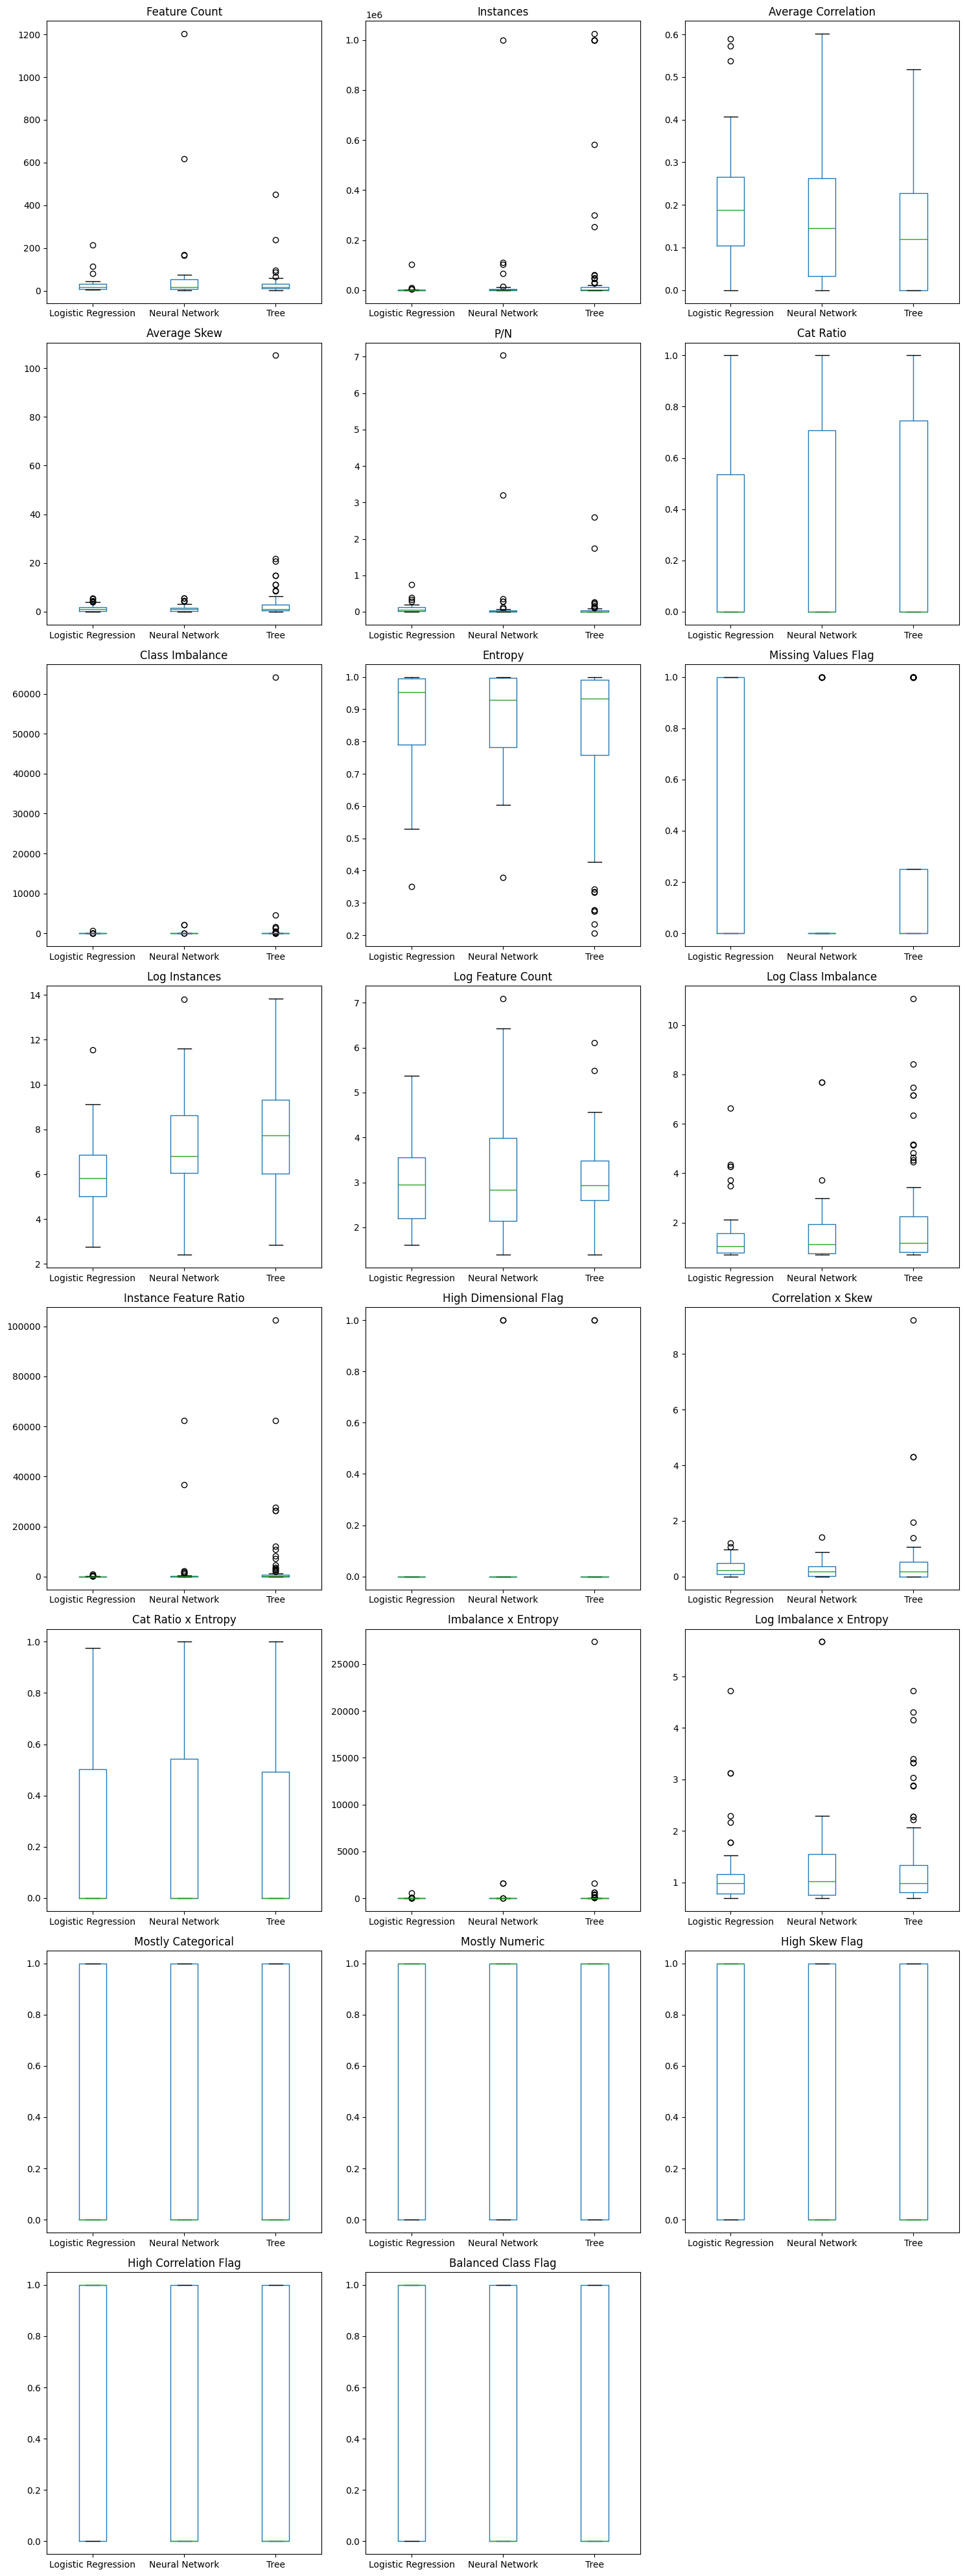

In [5]:
def plot_boxplots_grid(X, y, cols_per_row=3):
    df = X.copy()
    df["Label"] = y

    numeric_cols = X.select_dtypes(include="number").columns

    n = len(numeric_cols)
    rows = (n + cols_per_row - 1) // cols_per_row

    fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 5 * rows))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        df.boxplot(column=col, by="Label", ax=axes[i], grid=False)
        axes[i].set_title(col)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")

    # remove unused plots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

plot_boxplots_grid(X, y)

In [9]:
# Imports
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

import pandas as pd
import numpy as np
from google.colab import drive


# Preprocessing
def build_preprocessor(X: pd.DataFrame):

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [col for col in X.columns if col not in numeric_cols]

    numeric_pipeline = SklearnPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = SklearnPipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ])

    return preprocessor


# Feature Engineering
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["Log Instances"] = np.log1p(df["Instances"])
    df["Log Feature Count"] = np.log1p(df["Feature Count"])
    df["Log Class Imbalance"] = np.log1p(df["Class Imbalance"])
    df["Log Imbalance x Entropy"] = df["Log Class Imbalance"] * df["Entropy"]

    df["Missing Values Flag"] = (
        df["Missing Values"]
        .astype(str)
        .str.lower()
        .isin(["yes", "true", "1"])
        .astype(int)
    )

    return df


# Load Data
drive.mount("/content/drive")

file_path = "/content/drive/MyDrive/College/Current Courses/Advanced Machine Learning/Project/Data/Data.xlsx"
sheet_name = "Final_Data"

df = pd.read_excel(file_path, sheet_name=sheet_name, engine="openpyxl")

df = add_engineered_features(df)


# Select Features / Target
# Dropped weak / mostly constant engineered features
feature_cols = [
    "P/N",
    "Cat Ratio",
    "Average Correlation",


    # limited engineered features
    "Log Instances",
    "Log Feature Count",
    "Log Class Imbalance",
    "Log Imbalance x Entropy",
    "Missing Values Flag"
]

X = df[feature_cols].copy()
y = df["Recommended Algorithm"].copy()


# Build Model Pipeline
preprocessor = build_preprocessor(X)

model = RandomForestClassifier()

pipe = SklearnPipeline([
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=5)),
    ("model", model)
])


# Cross Validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipe,
    X,
    y,
    cv=cv,
    scoring=["f1_macro", "accuracy"],
    return_train_score=False,
    error_score="raise"
)

f1_scores = cv_results["test_f1_macro"]
accuracy_scores = cv_results["test_accuracy"]

mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)
confidence = mean_f1 - std_f1

print("F1 Macro Scores:", f1_scores)
print("Mean F1:", mean_f1)
print("Std F1:", std_f1)
print("Confidence:", confidence)

print("\nAccuracy Scores:", accuracy_scores)
print("Mean Accuracy:", np.mean(accuracy_scores))


# Confusion Matrix
y_pred = cross_val_predict(
    pipe,
    X,
    y,
    cv=cv
)

labels = sorted(y.unique())

cm = confusion_matrix(
    y,
    y_pred,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

print("\nConfusion Matrix:")
print(cm_df)

print("\nClassification Report:")
print(classification_report(y, y_pred, labels=labels))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
F1 Macro Scores: [0.53055219 0.55396825 0.51576448]
Mean F1: 0.5334283096759557
Std F1: 0.015728659126320512
Confidence: 0.5176996505496352

Accuracy Scores: [0.57142857 0.625      0.57142857]
Mean Accuracy: 0.5892857142857143

Confusion Matrix:
                     Logistic Regression  Neural Network  Tree
Logistic Regression                   15               5    21
Neural Network                         9              15    15
Tree                                  21               3    64

Classification Report:
                     precision    recall  f1-score   support

Logistic Regression       0.33      0.37      0.35        41
     Neural Network       0.65      0.38      0.48        39
               Tree       0.64      0.73      0.68        88

           accuracy                           0.56       168
          macro avg       0.54      0.49  

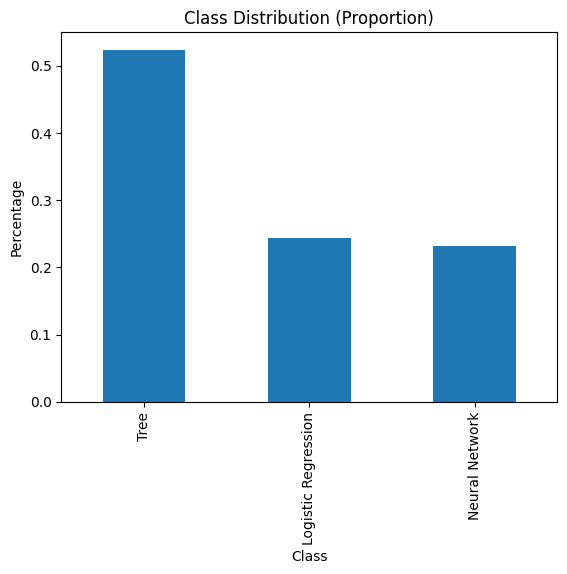

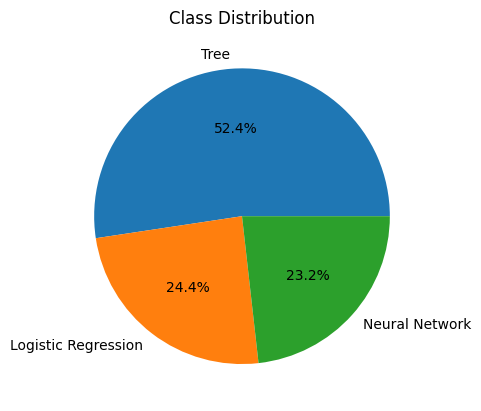

In [11]:
probs = y.value_counts(normalize=True)

probs.plot(kind='bar')
plt.title("Class Distribution (Proportion)")
plt.xlabel("Class")
plt.ylabel("Percentage")
plt.show()

y.value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Class Distribution")
plt.ylabel("")
plt.show()

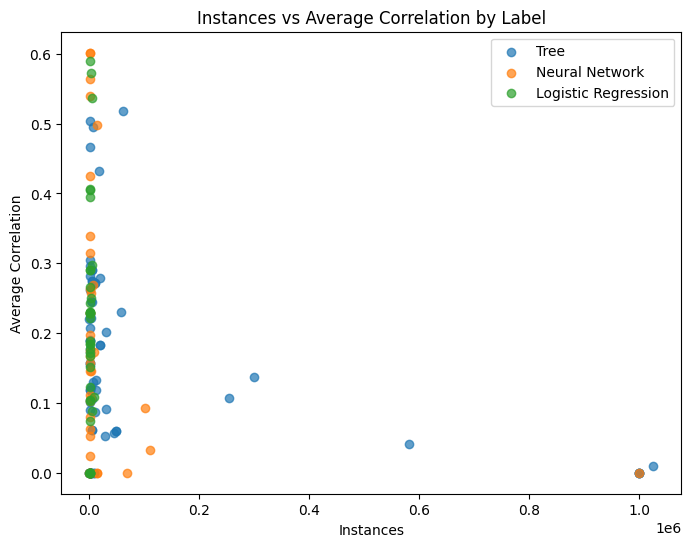

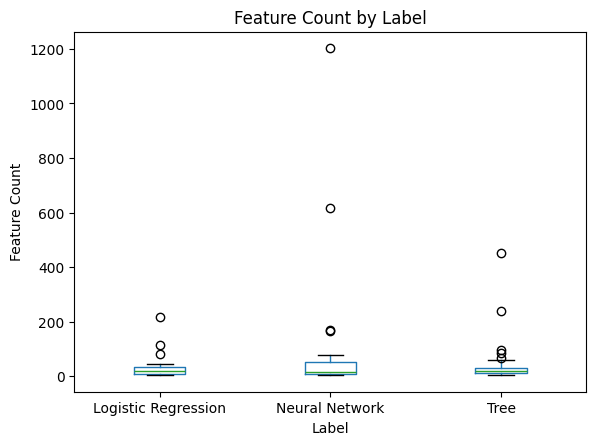

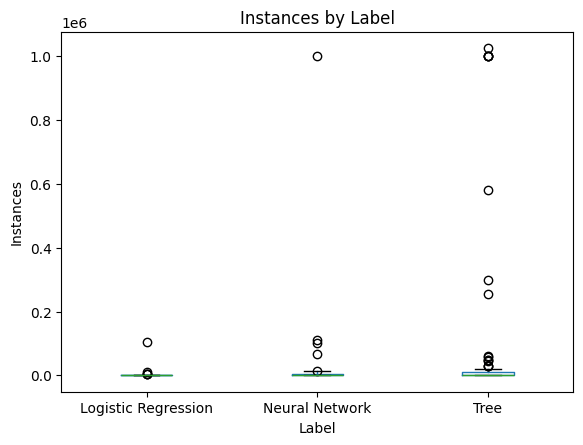

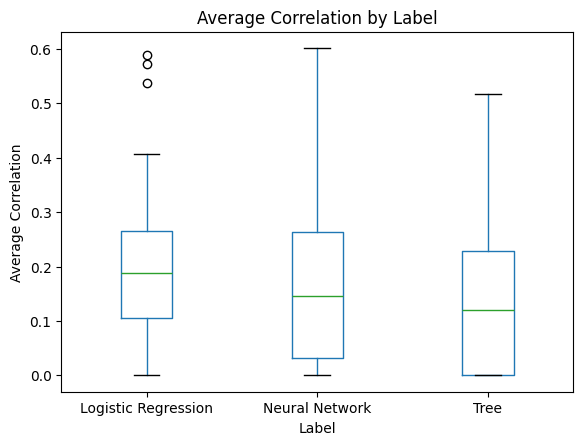

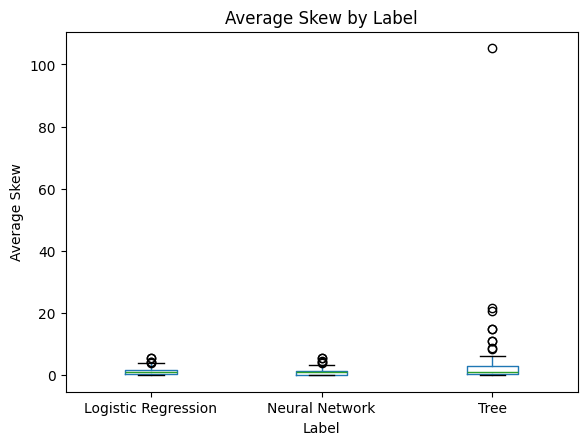

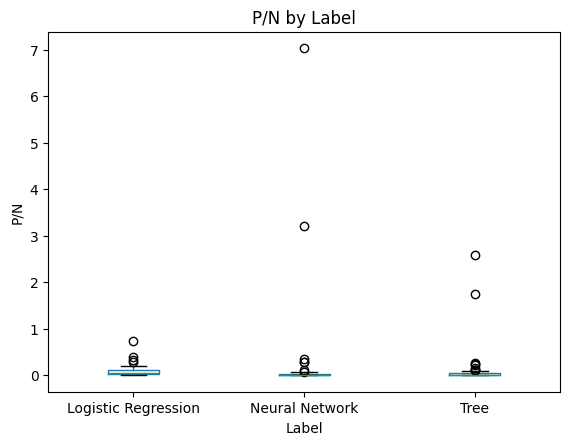

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_boxplots_by_label(X, y, max_features=10):
    num_cols = X.select_dtypes(include="number").columns[:max_features]

    for col in num_cols:
        plot_df = pd.DataFrame({
            col: X[col],
            "Label": y
        })

        plot_df.boxplot(column=col, by="Label", grid=False)
        plt.title(f"{col} by Label")
        plt.suptitle("")
        plt.xlabel("Label")
        plt.ylabel(col)
        plt.show()

def plot_scatter_by_label(X, y, feature_x, feature_y):
  plt.figure(figsize=(8, 6))

  labels = y.unique()

  for label in labels:
      mask = y == label
      plt.scatter(X.loc[mask, feature_x], X.loc[mask, feature_y], label=label, alpha=0.7)

  plt.xlabel(feature_x)
  plt.ylabel(feature_y)
  plt.title(f"{feature_x} vs {feature_y} by Label")
  plt.legend()
  plt.show()

def plot_histograms_by_label(X, y, feature):
    plt.figure(figsize=(8, 6))

    for label in y.unique():
        plt.hist(X.loc[y == label, feature], alpha=0.5, label=label)

    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title(f"Distribution of {feature} by Label")
    plt.legend()
    plt.show()


num_cols = X.select_dtypes(include="number").columns
plot_scatter_by_label(X, y, num_cols[1], num_cols[2])
plot_boxplots_by_label(X, y, max_features=5)